# Multi-Output Non-Linear Regression

This notebook demonstrates how to use the `ml-engine-from-scratch` framework to solve a complex, multi-output regression task. 

Unlike classification tasks where the output is a discrete label, regression requires the network to predict continuous values. We will task our Multi-Layer Perceptron (MLP) with simultaneously learning two distinct continuous functions from a single input $x$:
1. A smooth, low-frequency sine wave.
2. A highly complex, multi-frequency wave.

This serves as a practical demonstration of the **Universal Approximation Theorem**, showing how deep networks can map 1D inputs to multi-dimensional continuous spaces.

In [46]:
import ml_framework as ml
import matplotlib.pyplot as plt
import numpy as np

# General Configuration
N_SAMPLES = 10000
N_IN_FEATURES = 1
N_OUT_FEATURES = 2
X_MIN = -1.0
X_MAX = 1.0

rng = np.random.default_rng(seed=42)

## 1. Data Generation and Initial Visualization
We will generate 10,000 random scalar inputs $x \in [-1, 1]$. 
From these inputs, we generate two targets with added Gaussian noise:
* $y_1 = \sin(\pi x) + \epsilon$
* $y_2 = \sin(2x) + 0.5\cos(10x) + 0.25\sin(25x) + \epsilon$

Neural networks typically perform best when target variables are scaled. We will normalize both $y_1$ and $y_2$ to the $[0, 1]$ range before splitting the dataset.

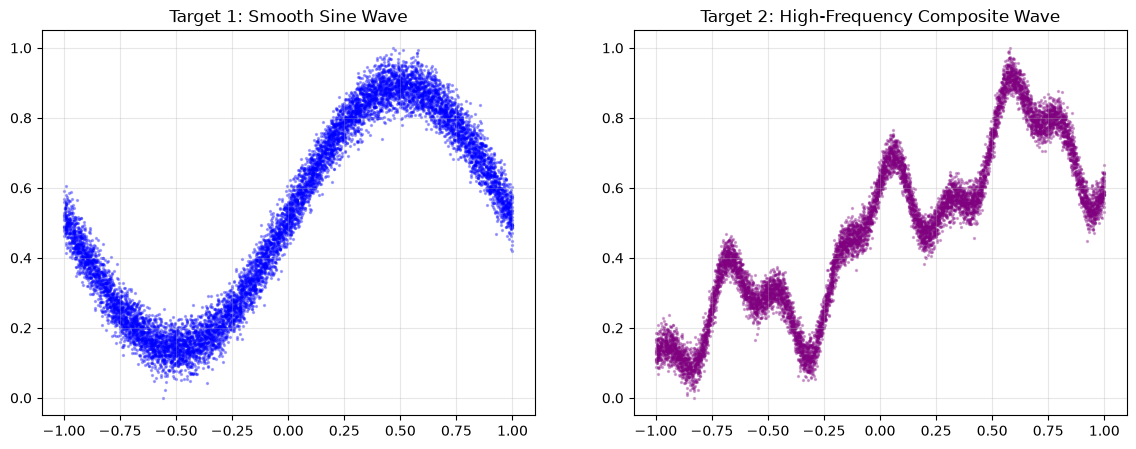

Train shapes: X=(8000, 1), y=(8000, 2)
Test shapes: X=(2000, 1), y=(2000, 2)


In [47]:
# Generate inputs
x_data = X_MIN + (X_MAX - X_MIN) * rng.random((N_SAMPLES, N_IN_FEATURES))

# Generate targets with noise
noise = rng.standard_normal((N_SAMPLES, 1)) * 0.1
y1 = np.sin(np.pi * x_data[:, 0:1]) + noise
y2 = np.sin(2 * x_data[:, 0:1]) + 0.5 * np.cos(10 * x_data[:, 0:1]) + 0.25 * np.sin(25 * x_data[:, 0:1]) + noise
y_data = np.hstack((y1, y2))

# Normalize Targets to [0, 1] using Min-Max scaling
y_data[:, 0] = (y_data[:, 0] - np.min(y_data[:, 0])) / (np.max(y_data[:, 0]) - np.min(y_data[:, 0]))
y_data[:, 1] = (y_data[:, 1] - np.min(y_data[:, 1])) / (np.max(y_data[:, 1]) - np.min(y_data[:, 1]))

# Initial Visualization of the Raw Data
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.title('Target 1: Smooth Sine Wave', fontsize=12)
plt.scatter(x_data, y_data[:, 0], color='blue', s=2, alpha=0.3)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.title('Target 2: High-Frequency Composite Wave', fontsize=12)
plt.scatter(x_data, y_data[:, 1], color='purple', s=2, alpha=0.3)
plt.grid(alpha=0.3)
plt.show()

# Train/Test Splitting (80/20)
split_idx = int(N_SAMPLES * 0.8)
X_train, X_test = x_data[:split_idx], x_data[split_idx:]
y_train, y_test = y_data[:split_idx], y_data[split_idx:]

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

## 2. Neural Network Architecture
Regression of highly non-linear, high-frequency functions requires sufficient depth and width. 

*Engineering Note:* We are using the **Hyperbolic Tangent (`Tanh`)** activation function here instead of `ReLU`. `Tanh` provides smooth, differentiable, and bounded non-linearities $[-1, 1]$, which often yield much smoother curve approximations for continuous mathematical functions compared to the sharp "corners" created by `ReLU` networks.

In [48]:
# Model Architecture
model = ml.Sequential([
    ml.LinearLayer(in_features=1, out_features=32, rng=rng),
    ml.ActivationLayer(func=ml.Tanh, derivative=ml.TanhDerivative),
    
    ml.LinearLayer(in_features=32, out_features=32, rng=rng),
    ml.ActivationLayer(func=ml.Tanh, derivative=ml.TanhDerivative),
    
    ml.LinearLayer(in_features=32, out_features=64, rng=rng),
    ml.ActivationLayer(func=ml.Tanh, derivative=ml.TanhDerivative),
    
    ml.LinearLayer(in_features=64, out_features=2, rng=rng)
])

print("Model Architecture Initialized:")
print(model)

# For regression, Mean Squared Error (MSE) is the standard loss metric
loss_fn = ml.MSELoss()
optimizer = ml.Adam(learning_rate=0.001)

Model Architecture Initialized:
Sequential(
	(0): LinearLayer(in_features=1, out_features=32, bias=True)
	(1): ActivationLayer(func=Tanh)
	(2): LinearLayer(in_features=32, out_features=32, bias=True)
	(3): ActivationLayer(func=Tanh)
	(4): LinearLayer(in_features=32, out_features=64, bias=True)
	(5): ActivationLayer(func=Tanh)
	(6): LinearLayer(in_features=64, out_features=2, bias=True)
)


## 3. Model Training
We train the model for 1000 epochs. Because we are optimizing a continuous output, we track the Mean Squared Error (MSE). We shuffle the data at the start of every epoch to ensure stochasticity in our mini-batches.

In [49]:
EPOCHS =1000
TEST_FREQ = 10
BATCH_SIZE = 128

loss_values = []
val_loss_values = []

for epoch in range(EPOCHS):
    model.train()
    
    # Shuffle training data
    indices = np.arange(X_train.shape[0])
    rng.shuffle(indices)
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    # Mini-batch training
    for start_idx in range(0, X_train.shape[0], BATCH_SIZE):
        end_idx = start_idx + BATCH_SIZE
        X_batch = X_train_shuffled[start_idx:end_idx]
        y_batch = y_train_shuffled[start_idx:end_idx]
        
        # Forward pass
        y_pred = model(X_batch)
        
        # Compute loss (caches y_pred and y_expected internally)
        loss_fn(y_predicted=y_pred, y_expected=y_batch)
        
        # Get the initial gradient from the MSE loss function
        initial_gradient = loss_fn.backward()
        
        # Backpropagation
        model.backward(initial_gradient)
        
        # Update weights
        optimizer.step(model)

    # Evaluation
    if (epoch + 1) % TEST_FREQ == 0 or epoch == 0:
        model.eval()
        train_pred = model(X_train)
        train_loss = loss_fn(y_predicted=train_pred, y_expected=y_train)
        loss_values.append(train_loss)
        
        test_pred = model(X_test)
        test_loss = loss_fn(y_predicted=test_pred, y_expected=y_test)
        val_loss_values.append(test_loss)
        print(f"Epoch {epoch + 1:4d}/{EPOCHS} | Train MSE: {train_loss:.6f} | Val MSE: {test_loss:.6f}")

Epoch    1/1000 | Train MSE: 0.012770 | Val MSE: 0.013132
Epoch   10/1000 | Train MSE: 0.005595 | Val MSE: 0.005732
Epoch   20/1000 | Train MSE: 0.004032 | Val MSE: 0.004147
Epoch   30/1000 | Train MSE: 0.003308 | Val MSE: 0.003330
Epoch   40/1000 | Train MSE: 0.002694 | Val MSE: 0.002740
Epoch   50/1000 | Train MSE: 0.002399 | Val MSE: 0.002428
Epoch   60/1000 | Train MSE: 0.002532 | Val MSE: 0.002549
Epoch   70/1000 | Train MSE: 0.002183 | Val MSE: 0.002216
Epoch   80/1000 | Train MSE: 0.002306 | Val MSE: 0.002348
Epoch   90/1000 | Train MSE: 0.002217 | Val MSE: 0.002260
Epoch  100/1000 | Train MSE: 0.002038 | Val MSE: 0.002071
Epoch  110/1000 | Train MSE: 0.001725 | Val MSE: 0.001763
Epoch  120/1000 | Train MSE: 0.001689 | Val MSE: 0.001721
Epoch  130/1000 | Train MSE: 0.001787 | Val MSE: 0.001836
Epoch  140/1000 | Train MSE: 0.001477 | Val MSE: 0.001545
Epoch  150/1000 | Train MSE: 0.001592 | Val MSE: 0.001674
Epoch  160/1000 | Train MSE: 0.001364 | Val MSE: 0.001430
Epoch  170/100

## 4. Learning Curves Analysis
Because MSE can drop rapidly in the first few epochs and then decrease exponentially slowly, it is often best visualized on a logarithmic scale (`semilogy`). This allows us to observe the fine-tuning behavior in the later epochs.

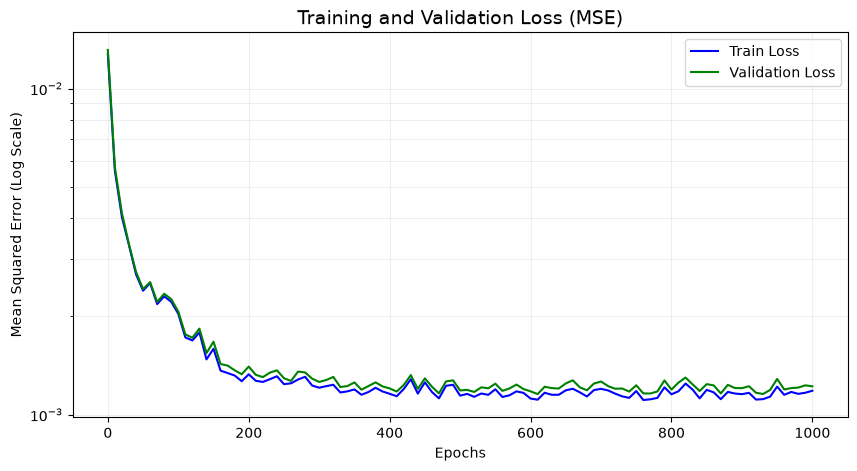

In [50]:
plt.figure(figsize=(10, 5))
plt.title('Training and Validation Loss (MSE)', fontsize=14)
plt.semilogy(TEST_FREQ*np.arange(len(loss_values)), loss_values, 'b-', linewidth=1.5, label='Train Loss')
plt.semilogy(TEST_FREQ*np.arange(len(loss_values)), val_loss_values, 'g-', linewidth=1.5, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

## 5. Regression Curve Visualization
To evaluate our model visually, we will generate a perfectly spaced array of points across our input domain and ask the model to predict the outputs. We can then overlay this predicted curve on top of our noisy training and testing data.

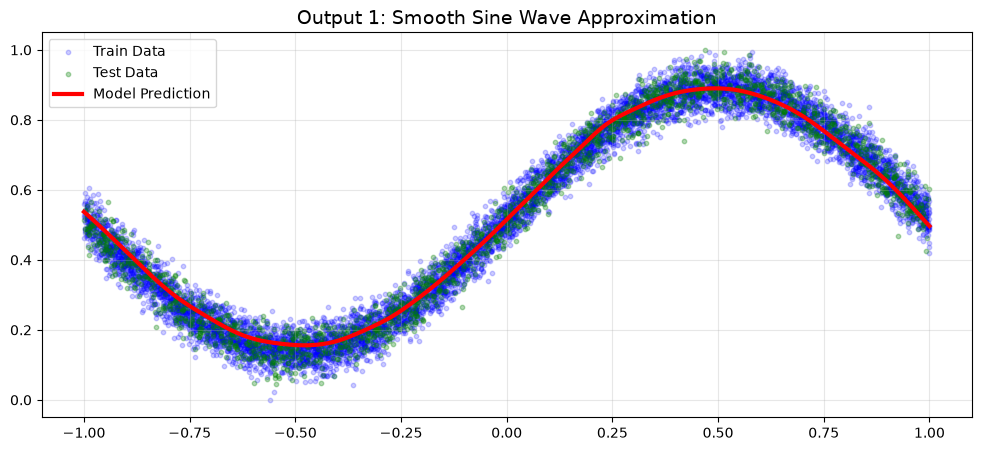

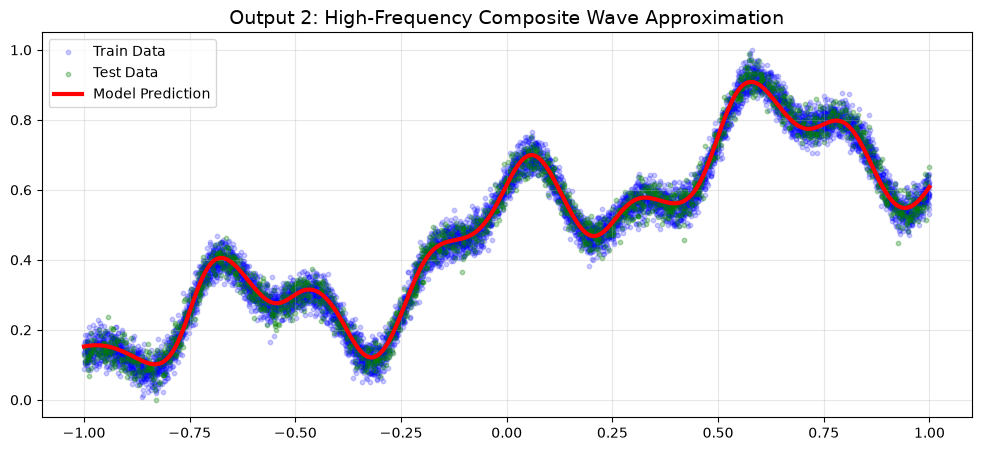

In [51]:
# Generate continuous inputs for a smooth evaluation curve
model.eval()
X_eval = np.linspace(X_MIN, X_MAX, 500).reshape(-1, 1)
y_pred_eval = model(X_eval)

# Plot Output 1
plt.figure(figsize=(12, 5))
plt.title('Output 1: Smooth Sine Wave Approximation', fontsize=14)
plt.scatter(X_train[:, 0], y_train[:, 0], color='blue', s=10, label='Train Data', alpha=0.2)
plt.scatter(X_test[:, 0], y_test[:, 0], color='green', s=10, label='Test Data', alpha=0.3)
plt.plot(X_eval[:, 0], y_pred_eval[:, 0], 'r-', linewidth=3, label='Model Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot Output 2
plt.figure(figsize=(12, 5))
plt.title('Output 2: High-Frequency Composite Wave Approximation', fontsize=14)
plt.scatter(X_train[:, 0], y_train[:, 1], color='blue', s=10, label='Train Data', alpha=0.2)
plt.scatter(X_test[:, 0], y_test[:, 1], color='green', s=10, label='Test Data', alpha=0.3)
plt.plot(X_eval[:, 0], y_pred_eval[:, 1], 'r-', linewidth=3, label='Model Prediction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Model Persistence: Saving and Loading
Training a complex model takes time and compute resources. A professional framework must be able to serialize (save) the learned weights to disk and deserialize (load) them later for inference without retraining.

We will save our trained model, instantiate a completely fresh, untrained architecture, and load the saved weights. Finally, we will plot the predictions of both models to verify they match perfectly.

### Save the Trained Model

In [52]:
# Save the trained model
save_path = "regression_model.pth"
model.save(filepath=save_path)
print(f"Model successfully saved to {save_path}")

Model saved successfully to regression_model.pth
Model successfully saved to regression_model.pth


### Load the Trained Model

Model loaded successfully from regression_model.pth
Model weights successfully loaded!


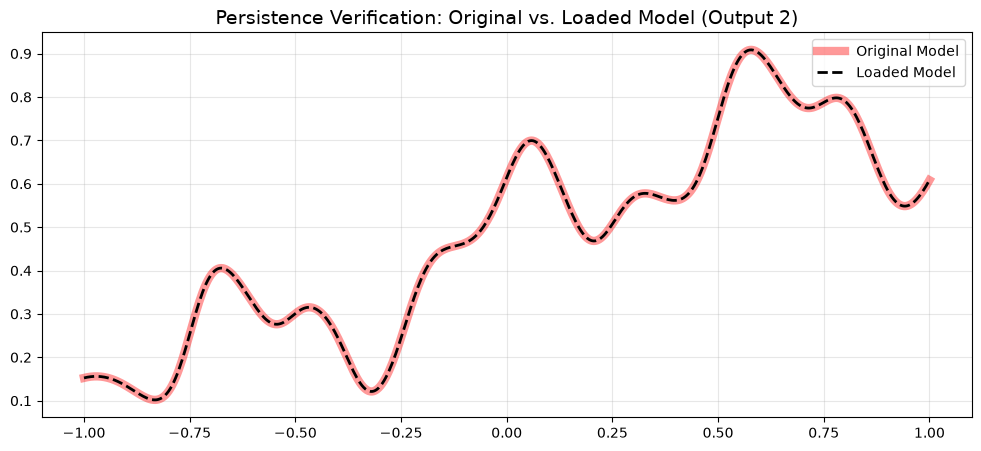

In [53]:
# Instantiate a fresh, untrained model with the same architecture
loaded_model = ml.Sequential([
    ml.LinearLayer(in_features=1, out_features=32, rng=rng),
    ml.ActivationLayer(func=ml.Tanh, derivative=ml.TanhDerivative),
    
    ml.LinearLayer(in_features=32, out_features=32, rng=rng),
    ml.ActivationLayer(func=ml.Tanh, derivative=ml.TanhDerivative),
    
    ml.LinearLayer(in_features=32, out_features=64, rng=rng),
    ml.ActivationLayer(func=ml.Tanh, derivative=ml.TanhDerivative),
    
    ml.LinearLayer(in_features=64, out_features=2, rng=rng)
])

# Load the trained weights into the fresh model
loaded_model.load(filepath=save_path)
print("Model weights successfully loaded!")

# Generate predictions using the loaded model
loaded_model.eval()
y_pred_loaded = loaded_model(X_eval)

# Visual verification
plt.figure(figsize=(12, 5))
plt.title('Persistence Verification: Original vs. Loaded Model (Output 2)', fontsize=14)

# Plot the original prediction as a thick, semi-transparent line
plt.plot(X_eval[:, 0], y_pred_eval[:, 1], color='red', linewidth=6, alpha=0.4, label="Original Model")

# Plot the loaded prediction as a thin dashed line over it
plt.plot(X_eval[:, 0], y_pred_loaded[:, 1], color='black', linestyle='--', linewidth=2, label="Loaded Model")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Conclusion and Spectral Bias

The `ml-engine-from-scratch` framework successfully learned to approximate a multi-dimensional function mapping.

**Architectural Insight (Spectral Bias):**
You may notice that the model approximates the smooth, low-frequency sine wave (Output 1) almost perfectly and very early in training. However, the high-frequency composite wave (Output 2) takes significantly more epochs to capture, and the peaks may be slightly smoothed out. 

This demonstrates a known phenomenon in Deep Learning called **Spectral Bias**: Neural networks naturally learn low-frequency functions easily and struggle to learn high-frequency variations. Solving this for complex physical simulations often requires techniques like *Fourier Features* or *Positional Encodings* (similar to those used in Transformers).